In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# 1. 构造数据
data = {
    'tumor_size': [1.2, 2.0, 3.5, 4.2, 4.8, 5.5, 6.0, 3.8],
    'age':        [45,  50,  55,  60,  52,  65,  70,  72],
    'cancer':     [0,   0,   0,   1,   1,   1,   1,   0]
}
df = pd.DataFrame(data)

X = df[['tumor_size', 'age']]   # 特征 input
y = df['cancer']                # 标签 output

# 2. 建立并训练一棵小树
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X, y)

# 3. 预测新病人
new_patient = [[4.3, 62]]       # [tumor_size, age]
print(tree.predict(new_patient))  # 输出可能是 [1]


[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


   max_depth  train_accuracy  test_accuracy
0        1.0        0.710000       0.680000
1        2.0        0.785714       0.736667
2        3.0        0.838571       0.826667
3        5.0        0.911429       0.886667
4        8.0        0.964286       0.883333
5       12.0        0.994286       0.860000
6        NaN        1.000000       0.856667


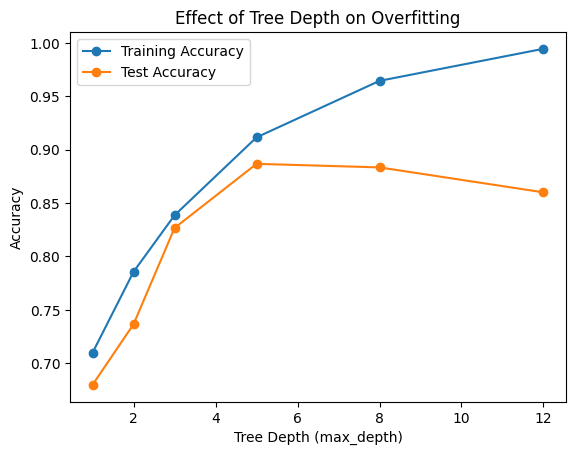

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. 生成一个更稳定的二分类数据集
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=4,
    n_redundant=2,
    n_clusters_per_class=2,
    class_sep=1.0,
    flip_y=0.03,
    random_state=42
)

X = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. 比较不同 max_depth 下的训练/测试表现
depths = [1, 2, 3, 5, 8, 12, None]
train_acc = []
test_acc = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

# 4. 结果汇总为表格（方便引用）
results = pd.DataFrame({
    "max_depth": depths,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc
})

print(results)

# 5. 可视化：训练 vs 测试准确率
plt.figure()
plt.plot(depths, train_acc, marker='o', label='Training Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')
plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Overfitting")
plt.legend()
plt.show()
